Translation


In [2]:
import numpy as np
import cv2 as cv

In [3]:
image=cv.imread("../data/colors.jpg")
cv.imshow("Original",image)
cv.waitKey(0)

-1

In [4]:
M=np.float32([[1,0,25],[0,1,50]]) # 25 is by how much it is hifted to right and 50 is by how much it is shifted down
shifted=cv.warpAffine(image,M,(image.shape[1],image.shape[0]))  
cv.imshow("Shifted down and right",shifted)
cv.waitKey(0)

-1

In [5]:
M=np.float32([[1,0,-25],[0,1,-50]]) # 25 is by how much it is hifted to right and 50 is by how much it is shifted down
shifted=cv.warpAffine(image,M,(image.shape[1],image.shape[0]))  
cv.imshow("Shifted up and left",shifted)
cv.waitKey(0)

-1

In [6]:
def translate(image,x,y):
    M=np.float32([[1,0,x],[0,1,y]]) 
    shifted=cv.warpAffine(image,M,(image.shape[1],image.shape[0]))  
    return shifted


In [7]:
shifted=translate(image,100,50)
cv.imshow("Shifted",shifted)
cv.waitKey(0)

-1

In [8]:
(height,width)=image.shape[:2]
center=(width//2,height//2)
M=cv.getRotationMatrix2D(center,45,1.0) # center, angle of rotation, scale
rotated=cv.warpAffine(image,M,(width,height))
cv.imshow("Rotated by 45 degrees",rotated)
cv.waitKey(0)

-1

In [9]:
#rotation function
def rotate(image,angle,scale=1.0):
    (height,width)=image.shape[:2]
    center=(width//2,height//2)
    M=cv.getRotationMatrix2D(center,angle,scale) 
    rotated=cv.warpAffine(image,M,(width,height))
    return rotated

In [10]:
rotated=rotate(image,45)
cv.imshow("Rotated by 45 degrees",rotated)
cv.waitKey(0)

-1

Resize

In [11]:
height=image.shape[0]
width=image.shape[1]
r=50/height
dim=(int(width*r),50) #(height,width)
resized=cv.resize(image,dim,interpolation=cv.INTER_AREA)
cv.imshow("Resized(height   )",resized)   
cv.waitKey(0) 

-1

In [12]:
import imutils

In [13]:
resized=imutils.resize(image,width=50)
cv.imshow("Resized(height ) with imutils",resized)
cv.waitKey(0)

-1

In [14]:
#function to display image
def display(title,image):
    cv.imshow(title,image)
    cv.waitKey(0)

In [15]:
display("Original",image)

## flipping

In [16]:
flip=cv.flip(image,1) # 0 for vertical, 1 for horizontal , -1 for both
display("Flipped Horizontally",flip)    


In [17]:
flip=cv.flip(image,0) # 0 for vertical, 1 for horizontal , -1 for both
display("Flipped vertically",flip)    

In [18]:
flip=cv.flip(image,-1) # 0 for vertical, 1 for horizontal , -1 for both
display("Flipped vertically and horizontally",flip)   

### Crop

In [19]:
cropped=image[30:120,240:335]
display("cropped image",cropped)

### Arithmetics

In [20]:
M=np.ones(image.shape,dtype="uint8")*150 #(as we increase it become darker)
subtracted=cv.subtract(image,M)
display("image subtracted",subtracted) #this will change its color 

In [21]:
rectangle=np.zeros((300,300),dtype='uint8')
cv.rectangle(rectangle,(25,25),(270,275),255,-1)
cv.imshow("rectangle",rectangle)

circle=np.zeros((300,300),dtype='uint8')
cv.circle(circle,(150,150),(150),255,-1)
cv.imshow("circle",circle)

cv.waitKey(0)

-1

###     Bitwise operations

In [22]:
bitwiseand=cv.bitwise_and(rectangle,circle)
cv.imshow("bitise and",bitwiseand)
cv.waitKey(0)

-1

In [23]:
bitwiseor=cv.bitwise_or(rectangle,circle)
cv.imshow("bitise or",bitwiseor)
cv.waitKey(0)

-1

In [24]:
bitwisxor=cv.bitwise_xor(rectangle,circle)
cv.imshow("bitise xor",bitwisxor)
cv.waitKey(0)

-1

In [25]:
bitwisnot=cv.bitwise_not(rectangle,circle)
cv.imshow("bitise not",bitwisnot)
cv.waitKey(0)

-1

### Masking

In [26]:
mask=np.zeros(image.shape[:2],dtype='uint8')
height=image.shape[1]
width=image.shape[0]
(cX,cY)=(height//2,width//2)
cv.rectangle(mask,(cX-75,cY-75),(cX+75,cY+75),255,-1)#255 to be white and -1 to be filled
cv.imshow("masked",mask)
cv.waitKey(0)

-1

In [27]:
masked_image=cv.bitwise_and(image,image,mask=mask)
cv.imshow("masked_image",masked_image)
cv.waitKey(0)

-1

### Color space

In [28]:
gray=cv.cvtColor(image,cv.COLOR_BGR2GRAY)
cv.imshow("gray",gray)

hsv=cv.cvtColor(image,cv.COLOR_BGR2HSV)
cv.imshow("hsv",hsv)

lab=cv.cvtColor(image,cv.COLOR_BGR2LAB)
cv.imshow("lab",lab)
cv.waitKey(0)

-1

### Histograms

In [31]:
import matplotlib.pyplot as plt
image=cv.imread("../data/grayscale_image.jpg")
image=cv.cvtColor(image,cv.COLOR_BGR2GRAY)
cv.imshow("gray",image)
cv.waitKey(0)


-1

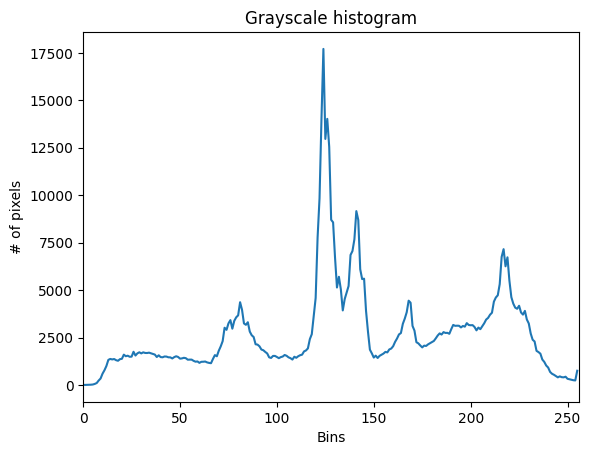

In [34]:
hist=cv.calcHist([image],[0],None,[256],[0,256])
plt.figure()
plt.title("Grayscale histogram")
plt.xlabel("Bins")#binaries
plt.ylabel("# of pixels")
plt.plot(hist)
plt.xlim([0,256])
plt.show()


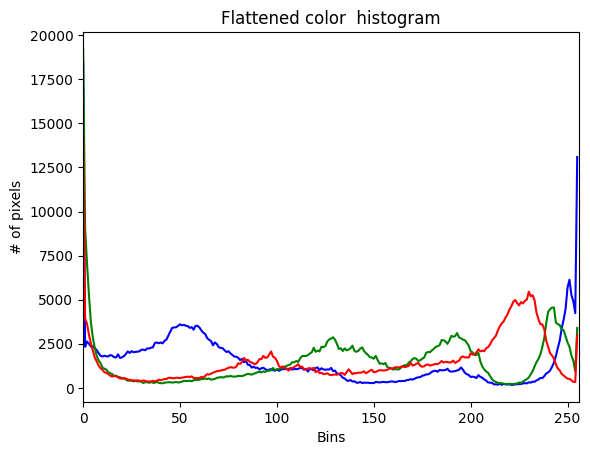

In [37]:
image=cv.imread("../data/colors.jpg")
chans=cv.split(image)
colors=('b','g','r')
plt.figure()
plt.title("Flattened color  histogram")
plt.xlabel("Bins")
plt.ylabel("# of pixels")
for (chan,color) in zip(chans,colors):
    hist=cv.calcHist([chan],[0],None,[256],[0,256])
    plt.plot(hist,color=color)
    
    plt.xlim([0,256])
    plt.show

### smooothing and bluring

In [43]:
image=cv.imread("../data/colors.jpg")
#hstack to show many image next to each others 
blurred=np.hstack([ 
    cv.blur(image,(3,3)),
    cv.blur(image,(5,5)),
    cv.blur(image,(8,8))
])
cv.imshow("blured image",blurred)
cv.waitKey(0)

-1

In [47]:
image=cv.imread("../data/colors.jpg")
blurred1=np.hstack([ 
    cv.GaussianBlur(image,(3,3),0),
    cv.GaussianBlur(image,(5,5),0),
    cv.GaussianBlur(image,(7,7),0)
])
cv.imshow("GaussianBlur image",blurred1)
cv.waitKey(0)

-1

In [48]:
blurred1=np.hstack([ 
    cv.medianBlur(image,3),
     cv.medianBlur(image,5),
      cv.medianBlur(image,7) 
])
cv.imshow("medianBlur image",blurred1)
cv.waitKey(0)

-1